# Odločitvena drevesa

Pri logičnem sklepanju smo doslej predpostavljali, da je baza znanja že podana v obliki pravil (oziroma Hornovih stavkov), s katerimi lahko učinkovito sklepamo o novih dejstvih. V praksi, kot smo se že pogovorili v okviru uvodnega predavanja o strojnem učenju, je ročno pisanje takih pravil zamudno, drago in pogosto tudi nezanesljivo, saj mora strokovnjak vnaprej eksplicitno opisati vse pomembne vzorce, ki jih zaznava pri svojem sklepanju. Zato se naravno pojavi vprašanje, ali lahko bazo znanja za sklepanje gradimo samodejno kar iz primerov pravilnega sklepanja.

Odločitvena drevesa so za ta namen posebej zanimiva, ker se iz učne množice ne naučijo le napovednega modela, temveč model v **berljivi in transparentni obliki**. Vsaka pot od korena do lista drevesa predstavlja zaporedje pogojev pravila oblike »če ... potem ...«, list pa podaja sklep. Zato lahko naučeno drevo razumemo kot množico pravil. Takšna pravila lahko nato po potrebi preoblikujemo v Hornove stavke, ki so posebej primerni za učinkovito sklepanje z veriženjem naprej ali nazaj.

S strojnim učenjem tako nadomestimo potrebo po ročnem pisanju pravil. Namesto da bi strokovnjak sam sestavljal bazo znanja, podamo algoritmu učno množico primerov pravilnega sklepanja, iz katere se model nauči, kateri pogoji vodijo do katerega zaključka. Pri tem želimo, da so naučena pravila hkrati dovolj natančna in dovolj preprosta, da jih lahko človek preveri, razume in po potrebi tudi popravi.

Enostaven primer odločitvenega drevesa za odločitev o odobritvi posojila je prikazan na sliki {ref}`fig-odlocitveno-drevo`.

```{figure} ../materiali/odlocitveno-drevo-posojilo.png
---
name: fig-odlocitveno-drevo
---
Primer enostavnega odločitvenega drevesa za odločitev o odobritvi posojila.
```

Odločitveno drevo s slike lahko zapišemo kot štiri pravila, kjer vsako pravilo ustreza enemu od listov:

1. Če `zaposlen = ne`, potem `posojilo = zavrni`.
2. Če `zaposlen = da` in `dolg <= 500`, potem `posojilo = odobri`.
3. Če `zaposlen = da` in `dolg > 500` in `porok = da`, potem `posojilo = odobri`.
4. Če `zaposlen = da` in `dolg > 500` in `porok = ne`, potem `posojilo = zavrni`.

Če ciljno spremenljivko razumemo kot logični sklep, lahko takšna pravila neposredno beremo tudi kot Hornove implikacije, na primer
$$
(Zaposlen(x) \land Majhen\_dolg(x)) \implies Odobri(x).
$$

Zato odločitvena drevesa niso le napovedni modeli, temveč tudi orodje za samodejno učenje razložljivih pravil.

Predavanje povzema vsebino prvega dela poglavja _8 Tree-Based Models_ (razdelek 8.1) učbenika {cite}`james2023islrp`, ki je dostopen na naslovu [https://www.statlearning.com/](https://www.statlearning.com/).

## Formalna definicija odločitvenih dreves

Naj bo $S$ podatkovna množica za nadzorovano učenje z napovednimi spremenljivkami $X_1, X_2, \dots, X_p$ in ciljno spremenljivko $Y$. Spomnimo se, vsak primer v tej množici je $(p+1)$-terica oblike $\left< x_1, x_2, \dots, x_p, y \right>$, ki jo pogosto krajše zapišemo kot $\left< \boldsymbol{x}, y \right>$.

Odločitveno drevo je usmerjeno drevo s tremi vrstami vozlišč:

- **koren**, ki predstavlja celotno učno množico $S$,
- **notranja vozlišča**, ki izvedejo test nad vrednostjo ene od napovednih spremenljivk,
- **listi** (tudi končna vozlišča), ki podajo napoved vrednosti ciljne spremenljivke.

Ker se v teh zapiskih omejimo na **binarna odločitvena drevesa**, vsakemu notranjemu vozlišču $v$ pripada test $\tau_v(\boldsymbol{x})$ z dvema možnima izidoma, $\top$ in $\bot$. Če je $v$ končno vozlišče (list) $l$, mu pripada napoved $\hat{y}_l$. Za nov primer $\boldsymbol{x}_0$ napovedovanje začnemo v korenu. V vsakem notranjem vozlišču izvedemo pripadajoči test nad vrednostmi $\boldsymbol{x}_0$ in sledimo veji $\top$ ali $\bot$, ki ustreza izidu testa, dokler ne pridemo do lista $l(\boldsymbol{x}_0)$. Napoved drevesa $m$ je zato
$$
m(\boldsymbol{x}_0) = \hat{y}_{l(\boldsymbol{x}_0)}.
$$

Pri odločitvenih drevesih igra pomembno vlogo povezava med vozlišči drevesa in množicami učnih primerov, ki ustrezajo vozliščem. Korenu $r$ pripišemo celotno učno množico $S_r = S$. Če notranje vozlišče $v$ vsebuje primere $S_v$ in test $\tau_v$ ima dva možna izida $\top$ in $\bot$, potem ustreznima otrokoma pripišemo podmnožici
$$
S_{v,\top} = \{\left< \boldsymbol{x}, y \right> \in S_v \colon \tau_v(\boldsymbol{x}) = \top\},
\qquad
S_{v,\bot} = \{\left< \boldsymbol{x}, y \right> \in S_v \colon \tau_v(\boldsymbol{x}) = \bot\}.
$$

Tako vsakemu vozlišču pripada podmnožica učnih primerov. Iz podatkovnih množic, ki ustrezajo listom drevesa, lahko izračunamo lokalne napovedi. Pri klasifikaciji je napoved v listu običajno napovedana **najbolj pogosta vrednost ciljne spremenljivke**,
$$
\hat{y}_l = \arg\max_{c \in D_Y} |\{\left< \boldsymbol{x}, y \right> \in S_l \colon y = c\}|,
$$

pri regresiji pa navadno **povprečna vrednost** ciljne spremenljivke,
$$
\hat{y}_l = \frac{1}{|S_l|} \sum_{\left< \boldsymbol{x}, y \right> \in S_l} y.
$$

Odločitveno drevo lahko razumemo tudi geometrijsko. Prostor napovednih spremenljivk
$$
D_{\boldsymbol{X}} = D_{X_1} \times D_{X_2} \times \dots \times D_{X_p}
$$
drevo razbije na $k$ disjunktnih regij
$$
D_{\boldsymbol{X}} = \bigcup_{i=1}^k R_i,
\qquad
\forall i \neq j\colon R_i \cap R_j = \emptyset.
$$
Vsaka regija $R_i$ ustreza enemu listu drevesa. V binarnem drevesu vsak test v notranjem vozlišču razbije trenutni prostor na dve disjunktni podmnožici, ki ustrezata vejama $\top$ in $\bot$. Presek vseh podmnožic vzdolž poti od korena do nekega lista določi regijo tega lista.

Zato odločitveno drevo definira odsekoma konstantno funkcijo
$$
m \colon D_{X_1} \times D_{X_2} \times \dots \times D_{X_p} \to D_Y,
$$
ki jo lahko zapišemo kot
$$
m(\boldsymbol{x}) = \sum_{i=1}^k \mathbb{1}(\boldsymbol{x} \in R_i) \, c_i.
$$
Pri tem je $c_i \in D_Y$ napoved v listu, ki ustreza regiji $R_i$. Ker so regije disjunktne, vsak primer $\boldsymbol{x}$ pripada natanko eni regiji $R_{\boldsymbol{x}}$, zato je v zgornji vsoti natanko en člen različen od $0$ in velja $m(\boldsymbol{x}) = c_{\boldsymbol{x}}$.

## Algoritem TDIDT za učenje odločitvenih dreves

Osnovni algoritem iz Algoritma {ref}`alg-tdidt` za učenje odločitvenega drevesa iz podane učne podatkovne množice je **TDIDT** (_top-down induction of decision trees_). Drevo gradi rekurzivno od korena navzdol. V vsakem vozlišču poišče najboljši dopustni test nad napovednimi spremenljivkami. Nato izbrani test uporabi za razdelitev trenutne množice primerov na dve podmnožici in postopek gradnje rekurzivno ponovi na obeh nastalih podmnožicah.

```{code-block} text
:caption: Algoritem TDIDT za učenje odločitvenih dreves
:name: alg-tdidt
:linenos:

VHOD: S je učna podatkovna množica

TDIDT(S)
    if imajo vsi primeri v S isto vrednost ciljne spremenljivke then
        return list z lokalno napovedjo na S

    if velja ustavitveni pogoj then
        return list z lokalno napovedjo na S

    for vsak dopusten test τ na trenutnih napovednih spremenljivkah do
        izračunaj kakovost razdelitve, ki jo povzroči τ na S

    izberi najboljši test τ*
    ustvari notranje vozlišče s testom τ*

    S_⊤ = {⟨x, y⟩ iz S, za katere je τ*(x) = ⊤}
    S_⊥ = {⟨x, y⟩ iz S, za katere je τ*(x) = ⊥}

    ustvari levo poddrevo TDIDT(S_⊤)
    ustvari desno poddrevo TDIDT(S_⊥)

    return nastalo drevo
```

Algoritem TDIDT najprej preveri, ali je množica $S$ v trenutnem vozlišču že **čista** ali pa velja ustavitveni pogoj, na primer premajhno število primerov ali največja dovoljena globina. V obeh primerih vrne list z lokalno napovedjo na množici $S$. Sicer pregleda vse dopustne teste nad napovednimi spremenljivkami in izbere test $\tau^*$, ki ponudi najbolj kakovostno razdelitev primerov v dve podmnožici. Nato z izbranim testom oblikuje množici $S_\top$ in $S_\bot$ ter rekurzivno zgradi levo in desno poddrevo.

Poglejmo teste, ki jih uporabimo za različne tipe napovednih spremenljivk.

- Za **binarno spremenljivko** z vrednostma $0$ in $1$ uporabimo test oblike $X_j = 1$. Veja $\top$ ustreza primerom z vrednostjo $1$ spremenljivke $X_j$, veja $\bot$ pa primerom z vrednostjo $0$.
- Za **diskretno spremenljivko** izbiramo med testi oblike $X_j \in A$, kjer je $A$ neprazna prava podmnožica domene $D_{X_j}$ spremenljivke $X_j$. Veja $\top$ ustreza primerom z vrednostjo $X_j$ v množici $A$, veja $\bot$ pa preostalim primerom.
- Za **numerično spremenljivko** tipično iščemo prag $t$ za test oblike $X_j \leq t$. Veja $\top$ ustreza primerom, ki pogoj izpolnjujejo, veja $\bot$ pa primerom z vrednostjo $X_j > t$. Smiselne kandidate za prag dobimo iz vrednosti spremenljivke $X_j$ v učni množici primerov.

V vsakem vozlišču torej TDIDT rešuje optimizacijski problem: iz množice vseh dopustnih testov glede na tip napovedne spremenljivke izbere tistega, ki povzroči najbolj čisti podmnožici $S_\top$ in $S_\bot$. V naslednjem razdelku bomo formalizirali pojem čistosti podatkovne množice in s tem tudi kriterij za izbiro optimalnega testa.

## Čistost podatkovne množice in izbira testa

Srce algoritma TDIDT je mera, s katero ocenimo, kako homogena je množica primerov v vozlišču. Intuitivno želimo, da list vsebuje primere $\left< \boldsymbol{x}, y \right>$, ki so si glede ciljne spremenljivke $Y$ čim bolj podobni. V takem vozlišču je lokalna napoved enostavna in zanesljivejša.

Če napovedujemo **numerično ciljno spremenljivko**, čistost povezujemo z razpršenostjo vrednosti ciljne spremenljivke v vozlišču. Večja razpršenost ustreza manjši čistosti in obratni. Pogosta mera nečistosti je zato varianca oziroma povprečna kvadratna napaka glede na lokalno povprečno vrednost ciljne spremenljivke:
$$
I_{\mathrm{reg}}(S) = \frac{1}{|S|} \sum_{\left< \boldsymbol{x}, y \right> \in S} (y - \bar y_S)^2,
\qquad
\bar y_S = \frac{1}{|S|} \sum_{\left< \boldsymbol{x}, y \right> \in S} y.
$$

Premisli v katerih primerih je varianca numerične spremenljivke v podatkovni množici enaka 0.

Če napovedujemo **diskretno ciljno spremenljivko**, nas zanima, kako mešana je porazdelitev vrednosti ciljne spremenljivke v podatkovni množici, ki ustreza vozlišču. Naj bosta $p_c(S)$ delež primerov razreda $c$ v množici $S$ in $D_Y$ domena ciljnih vrednosti.

Pogosto uporabljeni meri nečistosti podatkovne množica sta entropija
$$
I_H(S) = - \sum_{c \in D_Y} p_c(S) \log_2 p_c(S),
$$

in indeks Gini
$$
I_G(S) = 1 - \sum_{c \in D_Y} p_c(S)^2.
$$

Premisli v katerih primerih sta entropija in indeks Gini diskretne spremenljivke v podatkovni množici enaka 0. Premisli tudi kdaj imata ti dve  meri nečistosti največjo možno vrednost in kakšna je ta vrednost.

Zdaj, ko znamo izmeriti nečistost, se lahko lotimo definicije ciljne funkcije za optimizacijski problem, ki nam omogoča izbiro najboljšega testa za razdelitev podatkovne množice na čim bolj čisti podmnožici. Razdelitev je dobra, če povzroči čim večjo spremembo nečistosti, ki jo opazujemo pred razdelitvijo in po razdelitvi:
$$
I_{\mathrm{split}}(S, \tau) = I(S) - \left( \frac{|S_{\top}|}{|S|} I(S_{\top}) + \frac{|S_{\bot}|}{|S|} I(S_{\bot}) \right).
$$

V zgornji formuli prvi člen, $I(S)$ ustreza nečistosti podatkovne množice $S$ pred uporabe testa $\tau$. Drugi člen je obteženo povprečje nečistosti podatkovnih množic levega in desnega otroka, ki ju dobimo z uporabo testa $\tau$. Najboljši test je tisti, kjer bo sprememba nečistoče največja, iščemo torej
$$
\max_{\tau} I_{\mathrm{split}}(S, \tau).
$$

Glede na to, da je prvi člen izraza za izračun $I_{\mathrm{split}}(S, \tau)$, neodvisen od testa $\tau$, lahko ta optimizacijski problem poenostavimo takole:
$$
\min_{\tau} \frac{|S_{\top}|}{|S|} I(S_{\top}) + \frac{|S_{\bot}|}{|S|} I(S_{\bot}).
$$

Poglejmo primer podatkovne množice delfini. V njej smo zbrali 10 primerov opazovanih živali, od tega 5 delfinov in 5 morskih živali, ki niso delfini.Ciljna spremenljivka $Y$ v podatkovni množici je `delfin` z domeno $D_Y = \{da, ne\}$. Napovedne spremenljivke so numerična spremenljivka `dolzina` ter tri (binarne) diskretne spremenljivke `skrge`, `kljun` in `zob`. Učna množica $S$ je podana v naslednji tabeli:

| primer | dolzina | skrge | kljun | zob | delfin |
| --- | --- | --- | --- | --- | --- |
| $e_1$ | 3 | ne | da | veliko | da |
| $e_2$ | 4 | ne | da | veliko | da |
| $e_3$ | 3 | ne | da | malo | da |
| $e_4$ | 5 | ne | da | veliko | da |
| $e_5$ | 5 | ne | da | malo | da |
| $e_6$ | 5 | da | da | veliko | ne |
| $e_7$ | 4 | da | da | veliko | ne |
| $e_8$ | 5 | da | ne | veliko | ne |
| $e_9$ | 4 | da | ne | veliko | ne |
| $e_{10}$ | 4 | ne | da | malo | ne |

Na učni množici velja
$$
p(\text{delfin} = \text{da}) = p(\text{delfin} = \text{ne}) = \frac{5}{10} = 0.5,
$$
zato je začetna nečistost izmerjena z indeksom Gini enaka
$$
I_G(S) = 1 - (0.5^2 + 0.5^2) = 0.5.
$$

Na tej učni množici so v korenu drevesa možni naslednji testi:

- `dolzina < 4`,
- `dolzina < 5`,
- `skrge \in \{da\}`,
- `kljun \in \{da\}`,
- `zob \in \{veliko\}`.

Poglejmo zdaj po korakih, kako ocenimo kakovost testa za spremenljivko `skrge`. Ker je `skrge` binarna spremenljivka, imamo en sam smiselni test
$$
\tau(\boldsymbol{x}) \equiv \text{skrge} \in \{\text{da}\}.
$$

Ta test razdeli učno množico na podmnožici $S_\top$ in $S_\bot$:

- $S_\top = \{e_6, e_7, e_8, e_9\}$, ker imajo ti primeri vrednost $\text{skrge} = \text{da}$,
- $S_\bot = \{e_1, e_2, e_3, e_4, e_5, e_{10}\}$, ker je pri teh primerih vrednost $\text{skrge} = \text{ne}$.

V množici $S_\top$ ni nobenega delfina, zato velja
$$
p(\text{delfin} = \text{da} \mid S_\top) = 0, \qquad p(\text{delfin} = \text{ne} \mid S_\top) = 1,
$$
in posledično
$$
I_G(S_\top) = 1 - (0^2 + 1^2) = 0.
$$

V množici $S_\bot$ je 5 delfinov in en primer živali, ki ni delfin, zato velja
$$
p(\text{delfin} = \text{da} \mid S_\bot) = \frac{5}{6}, \qquad p(\text{delfin} = \text{ne} \mid S_\bot) = \frac{1}{6},
$$
od tod pa dobimo
$$
I_G(S_\bot) = 1 - \left( \left(\frac{5}{6}\right)^2 + \left(\frac{1}{6}\right)^2 \right) = \frac{10}{36} \approx 0.278.
$$

Kakovost testa $\text{skrge} \in \{\text{da}\}$ oziroma ustrezne razdelitve izračunamo kot zmanjšanje nečistosti:
$$
I_{\mathrm{split}}(S, \tau) = I_G(S) - \left( \frac{|S_\top|}{|S|} I_G(S_\top) + \frac{|S_\bot|}{|S|} I_G(S_\bot) \right).
$$
Če vstavimo konkretne vrednosti, dobimo
$$
I_{\mathrm{split}}(S, \tau) = 0.5 - \left( \frac{4}{10} \cdot 0 + \frac{6}{10} \cdot 0.278 \right) \approx 0.333.
$$

To pomeni, da test precej zmanjša nečistost učne množice. Če nadaljujemo z izračuni po istem postopku kot zgoraj dobimo še kakovosti preostalih petih dopustnih testov takole:
- $\text{dolzina} < 4$: $I_{\mathrm{split}} = 0.125$,
- $\text{dolzina} < 5$: $I_{\mathrm{split}} = 0$,
- $\text{skrge} \in \{\text{da}\}$: $I_{\mathrm{split}} \approx 0.333$,
- $\text{kljun} \in \{\text{da}\}$: $I_{\mathrm{split}} = 0.125$,
- $\text{zob} \in \{\text{veliko}\}$: $I_{\mathrm{split}} \approx 0.0238$.

Izračunaj zgornje vrednosti zmanjševanja nečistosti posameznih testov.

Najboljši test v korenu je torej test na spremenljivki `skrge`, saj povzroči največje zmanjšanje nečistosti. Na takem konkretnem primeru lepo vidimo osnovno idejo TDIDT: v vsakem vozlišču izberemo test, ki podatke razdeli na čim bolj čisti podmnožici. V tem smislu je algoritem TDIDT požrešen, saj na vsakem primeru izbere najboljšo možno vrednost ciljne funkcije v tem trenutku, ne glede na izid nadaljnjih razdelitev množice.

## Sprotno in naknadno rezanje odločitvenih dreves

Če model $m$, podan z odločitvenim drevesom, pustimo rasti predolgo, lahko postane zelo velik in se začne preveč prilagajati učnim podatkom. Takšno drevo ima majhno učno napako, a pogosto slabše posplošuje (glej prejšnja predavanja). Zato odločitvena drevesa običajno **režemo** (angl. _pruning_) in s tem preprečimo njihovo pretirano rast in pretirano prileganje.

Pri sprotnem rezanju (angl. _pre-pruning_) rast drevesa ustavimo že med gradnjo. Tipični kriteriji so:
- največja dovoljena globina,
- najmanjše dovoljeno število primerov v vozlišču,
- najmanjše dovoljeno število primerov za nadaljnjo delitev,
- najmanjše zahtevano izboljšanje nečistosti.

Prednost sprotnega rezanja je hitrost in preprostost, slabost pa to, da lahko dobro poddrevo odrežemo prezgodaj, še preden se pokaže njegova prava vrednost globlje v drevesu.

Pri naknadnem rezanju (angl. _post-pruning_) najprej zgradimo dovolj veliko drevo $T_0$, nato pa iščemo manjša poddrevesa, ki bolje uravnotežijo natančnost in kompleksnost. Klasični pristop je cenovno občutljivo rezanje (angl. _cost-complexity pruning_), kjer za drevo $T$ definiramo kriterij
$$
R_\alpha(T) = R(T) + \alpha |L(T)|.
$$

Pri rezanju se odločamo tako, da je vrednost $R_\alpha(T)$ čim manjša, $R(T)$ mera napake drevesa na učni množici, $|L(T)|$ pa število listov drevesa $T$. Parameter $\alpha \ge 0$ določa, kako močno kaznujemo velika drevesa:
- pri $\alpha = 0$ nas zanima le napaka, zato navadno izberemo veliko drevo,
- pri večjem $\alpha$ postane pomembnejša tudi enostavnost drevesa, zato raje izberemo manjše drevo.

Postopek poteka takole. Najprej zgradimo veliko začetno drevo $T_0$. Za vsako notranje vozlišče $v$ pogledamo poddrevo $T_v$, ki raste iz tega vozlišča. Izračunamo, kako neugodno bi bilo, če bi celotno poddrevo $T?v$ nadomestili z enim samim listom. Temu pripada tako imenovana efektivna stopnja rezanja
$$ \alpha(T_v) = \frac{R(v) - R(T_v)}{|L(T_v)| - 1}, $$
kjer je $R(t)$ napaka, če poddrevo $T_v$ zamenjamo z enim listom, $R(T_V)$ pa napaka obstoječega poddrevesa. Najprej odrežemo tisto poddrevo $T_v$, ki ima najmanjšo efektivno vrednost $\alpha(T_v)$, saj nam prinese največje poenostavljenje za najmanjšo izgubo natančnosti. S ponavljanjem dobimo zaporedje vse manjših dreves
$$
T_0 \supset T_1 \supset T_2 \supset \cdots \supset T_k,
$$
iz katerega nato s prečnim preverjanjem lahko izberemo drevo z najboljšo oceno napovedne zmogljivosti na testnih primerih.

Predpostavimo, da neko poddrevo, naučeno na podatkovni množici delfinov iz prejšnjega razdelka, vsebuje tri liste in na učni množici doseže napako $R(T_v) = 0$, če pa ga zamenjamo z enim samim listom, dobimo napako $R(v) = 1/12$. Potem je
$$
\alpha(T_v) = \frac{1/12 - 0}{3 - 1} = \frac{1}{24}.
$$

To pomeni, da za vsako rezanje z $\alpha > 1/24$ to poddrevo ni več upravičeno: majhno izboljšanje učne napake ne odtehta dodatne kompleksnosti dveh dodatnih listov. Če imamo v drevesu še druga poddrevesa z večjo efektivno vrednostjo, bomo tega odrezali prej. S tem dobimo manjše, praviloma bolj stabilno drevo, ki se manj preprilega učnim podatkom.

Glavna ideja naknadnega rezanja je zato preprosta: **najprej dovolimo drevesu, da zajame veliko strukture, nato pa kontrolirano odstranimo dele, ki niso dovolj koristni glede na svojo kompleksnost**.

Na koncu si poglejmo še praktičen primer izbire optimalnega drevesa. Na podatkovni množici `iris` bomo primerjali vpliv parametra **sprotnega rezanja** `min_samples_leaf` in parametra **naknadnega rezanja** `ccp_alpha`. Kakovost posameznega drevesa bomo ocenjevali s 5-kratnim stratificiranim prečnim preverjanjem in z mero klasifikacijske točnosti. Poleg točnosti bomo za vsak par parametrov izračunali tudi povprečno velikost drevesa, merjeno s številom listov.

Najboljsi model: min_samples_leaf = 3, ccp_alpha = 0.000000
Ocenjena točnost = 0.9667, povprecno stevilo listov = 5.60


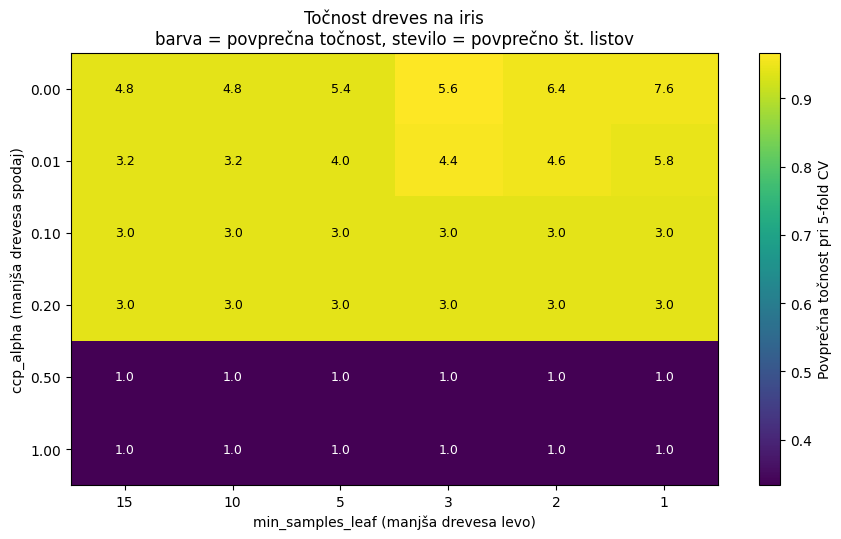

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree

podatki_iris = load_iris()
znacilke = podatki_iris.data
razredi = podatki_iris.target

precno_preverjanje = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parameter sprotnega rezanja uredimo tako, da so manjsa drevesa levo.
vrednosti_min_primerov_v_listu = np.array([15, 10, 5, 3, 2, 1])
vrednosti_ccp_alpha = np.array([0, 0.01, 0.1, 0.2, 0.5, 1])

mreza_tocnosti = np.zeros((len(vrednosti_ccp_alpha), len(vrednosti_min_primerov_v_listu)))
mreza_listov = np.zeros((len(vrednosti_ccp_alpha), len(vrednosti_min_primerov_v_listu)))

for indeks_alpha, alpha in enumerate(vrednosti_ccp_alpha):
    for indeks_min_list, min_primerov_v_listu in enumerate(vrednosti_min_primerov_v_listu):
        model_drevesa = DecisionTreeClassifier(
            random_state=42,
            min_samples_leaf=int(min_primerov_v_listu),
            ccp_alpha=float(alpha),
        )
        rezultati_preverjanja = cross_validate(
            model_drevesa,
            znacilke,
            razredi,
            cv=precno_preverjanje,
            scoring="accuracy",
            return_estimator=True,
        )
        mreza_tocnosti[indeks_alpha, indeks_min_list] = rezultati_preverjanja["test_score"].mean()
        mreza_listov[indeks_alpha, indeks_min_list] = np.mean(
            [drevo.get_n_leaves() for drevo in rezultati_preverjanja["estimator"]]
        )

# Izberemo najboljsi model: najvisja točnost, pri izenacenju pa manj listov.
najboljsi_indeksi = np.argwhere(mreza_tocnosti == mreza_tocnosti.max())
najboljsi_indeks_alpha, najboljsi_indeks_min_list = min(
    najboljsi_indeksi,
    key=lambda indeksni_par: mreza_listov[indeksni_par[0], indeksni_par[1]],
)
najboljsi_ccp_alpha = vrednosti_ccp_alpha[najboljsi_indeks_alpha]
najboljsi_min_vzorcev_v_listu = vrednosti_min_vzorcev_v_listu[najboljsi_indeks_min_list]
najboljsa_tocnost = mreza_tocnosti[najboljsi_indeks_alpha, najboljsi_indeks_min_list]
povprecno_stevilo_listov = mreza_listov[najboljsi_indeks_alpha, najboljsi_indeks_min_list]

print(
    f"Najboljsi model: min_samples_leaf = {najboljsi_min_vzorcev_v_listu}, "
    f"ccp_alpha = {najboljsi_ccp_alpha:.6f}"
)
print(
    f"Ocenjena točnost = {najboljsa_tocnost:.4f}, "
    f"povprecno stevilo listov = {povprecno_stevilo_listov:.2f}"
)

slika, os = plt.subplots(figsize=(9, 5.5))
prikaz = os.imshow(mreza_tocnosti, cmap="viridis", aspect="auto", origin="upper")

for indeks_alpha in range(len(vrednosti_ccp_alpha)):
    for indeks_min_list in range(len(vrednosti_min_vzorcev_v_listu)):
        os.text(
            indeks_min_list,
            indeks_alpha,
            f"{mreza_listov[indeks_alpha, indeks_min_list]:.1f}",
            ha="center",
            va="center",
            color="white" if mreza_tocnosti[indeks_alpha, indeks_min_list] < 0.9 else "black",
            fontsize=9,
        )

os.set_title("Točnost dreves na iris\nbarva = povprečna točnost, stevilo = povprečno št. listov")
os.set_xlabel("min_samples_leaf (manjša drevesa levo)")
os.set_ylabel("ccp_alpha (manjša drevesa spodaj)")
os.set_xticks(np.arange(len(vrednosti_min_primerov_v_listu)))
os.set_xticklabels(vrednosti_min_primerov_v_listu)
os.set_yticks(np.arange(len(vrednosti_ccp_alpha)))
os.set_yticklabels([f"{alpha:.2f}" for alpha in vrednosti_ccp_alpha])

barvna_lestvica = slika.colorbar(prikaz, ax=os)
barvna_lestvica.set_label("Povprečna točnost pri 5-fold CV")

plt.tight_layout()
plt.show()

Na dobljenem barvnem zemljevidu je barva posamezne celice sorazmerna s povprečno točnostjo drevesa, število v celici pa predstavlja povprečno število listov drevesa pri istem paru parametrov. Tako lahko hkrati opazujemo napovedno uspešnost in kompleksnost drevesa.

Na množici `iris` doseže najboljši rezultat drevo s parametroma sprotnega rezanja `min_samples_leaf = 3` in naknadnega rezanja, `ccp_alpha = 0`, ki pri 5-kratnem prečnem preverjanju doseže ocenjeno točnost približno $0.967$ in ima povprečno približno $5.6$ listov. Zato bi v tem primeru kot _optimalno drevo_ izbrali zmerno sprotno rezano drevo brez dodatnega naknadnega rezanja: bolj agresivno sprotno ali naknadno rezanje sicer še zmanjša drevo, vendar že nekoliko poslabša ocenjeno točnost.

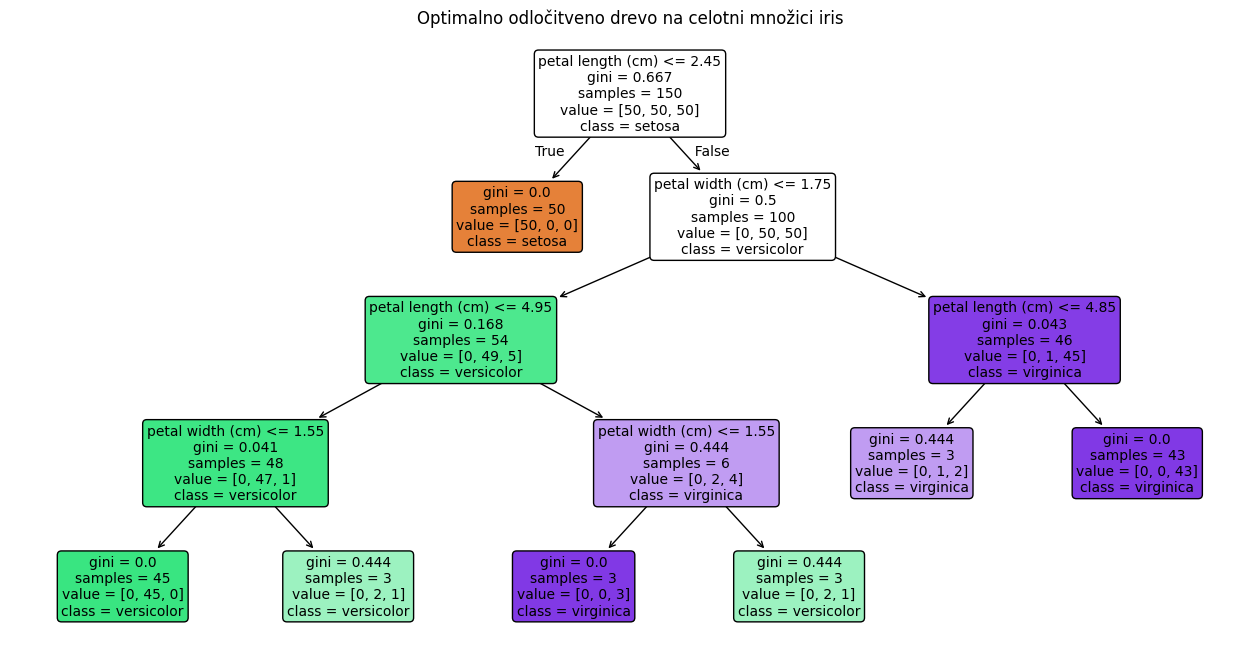

In [8]:
optimalno_drevo = DecisionTreeClassifier(
    random_state=42,
    min_samples_leaf=int(najboljsi_min_vzorcev_v_listu),
    ccp_alpha=float(najboljsi_ccp_alpha),
)
optimalno_drevo.fit(znacilke, razredi)

plt.figure(figsize=(16, 8))
plot_tree(
    optimalno_drevo,
    feature_names=podatki_iris.feature_names,
    class_names=podatki_iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Optimalno odločitveno drevo na celotni množici iris")
plt.show()


# Naloga za bonus točke

1. (5 točk, rok za oddajo: 4. maj) Izberi podatkovno množico za regresijo in primerjaj vsaj deset različnih odločitvenih dreves, ki jih dobimo z različnimi nastavitvami parametrov za sprotno in naknadno rezanje. Za vsako drevo oceni napovedno zmogljivost (v smislu napake ReRMSE) s prečnim preverjanjem. V kratkem komentarju pojasni, katero drevo bi izbral_a in zakaj.
<br/><br/>